In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import LinearSVC
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

In [2]:
# Load the dataset
df = pd.read_csv('dataset.csv')

In [3]:
# Display basic information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

### Data Preprocessing

In [4]:
# Check for missing values
df.isnull().sum()

Unnamed: 0          0
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

Since the empty values are in attributes such as artists, album_name and track_name that does not make significance in the analysis, we can just replace them with arbitary string without dropping any rows or columns.

In [4]:
df['artists'] = df['artists'].fillna('Unknown Artist')
df['album_name'] = df['album_name'].fillna('Unknown Album')
df['track_name'] = df['track_name'].fillna('Unknown Track')

In [6]:
df.isnull().sum()

Unnamed: 0          0
track_id            0
artists             0
album_name          0
track_name          0
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

### Business Insight 1: Predicting Hit Songs Using Popularity Correlations

In [5]:
# Preprocessing
threshold = df['popularity'].quantile(0.75)

df['hit_song'] = df['popularity'].apply(lambda x: 1 if x > threshold else 0)

X = df[['danceability', 'energy', 'loudness', 'acousticness', 'instrumentalness', 'liveness', 'tempo']]
y = df['hit_song']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

In [7]:
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

#### Decision Tree

In [8]:
model_dt = DecisionTreeClassifier(random_state=42)
model_dt.fit(X_train_res, y_train_res)
y_pred_dt = model_dt.predict(X_test)

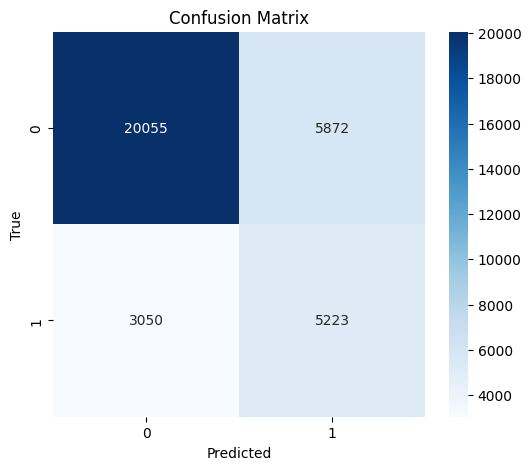

In [9]:
cm = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=model_dt.classes_, 
            yticklabels=model_dt.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [10]:
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.7391228070175438
              precision    recall  f1-score   support

           0       0.87      0.77      0.82     25927
           1       0.47      0.63      0.54      8273

    accuracy                           0.74     34200
   macro avg       0.67      0.70      0.68     34200
weighted avg       0.77      0.74      0.75     34200



#### SVM

In [11]:
model_svm = SVC()
model_svm.fit(X_train_res, y_train_res)
y_pred_svm = model_svm.predict(X_test)

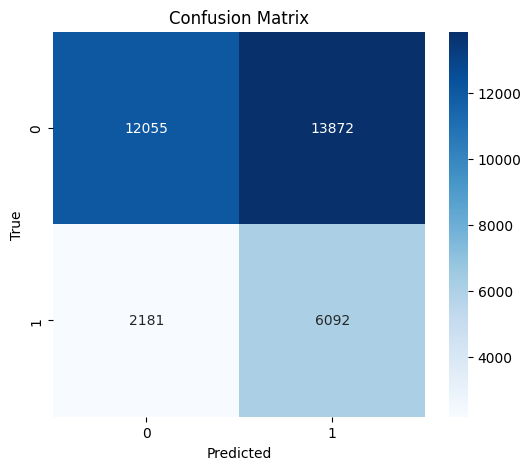

In [12]:
cm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=model_dt.classes_, 
            yticklabels=model_dt.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [13]:
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

SVM Accuracy: 0.5306140350877193
              precision    recall  f1-score   support

           0       0.85      0.46      0.60     25927
           1       0.31      0.74      0.43      8273

    accuracy                           0.53     34200
   macro avg       0.58      0.60      0.52     34200
weighted avg       0.72      0.53      0.56     34200



#### Random Forest

In [14]:
model_rf = RandomForestClassifier(random_state=42)
model_rf.fit(X_train_res, y_train_res)
y_pred_rf = model_rf.predict(X_test)


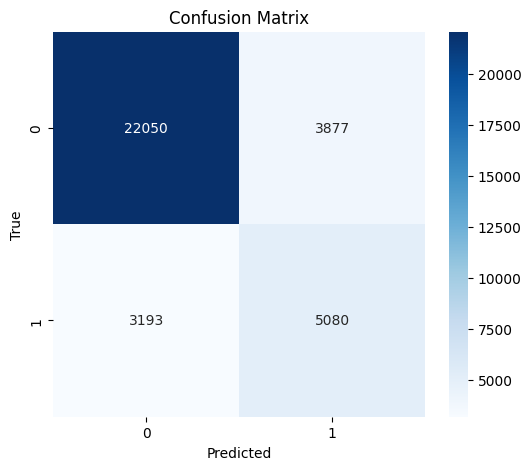

In [15]:
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=model_dt.classes_, 
            yticklabels=model_dt.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [16]:
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.7932748538011696
              precision    recall  f1-score   support

           0       0.87      0.85      0.86     25927
           1       0.57      0.61      0.59      8273

    accuracy                           0.79     34200
   macro avg       0.72      0.73      0.73     34200
weighted avg       0.80      0.79      0.80     34200

